# MNIST 手写数字识别 - Transformer 演示

本 notebook 展示如何使用 Transformer 编码器对 MNIST 手写数字进行分类。
模型将 28x28 的图像视为 784 个 token 的序列进行处理。

## 1. 环境设置

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. 配置参数

In [2]:
# 训练配置
config = {
    'data_dir': './mnist/data',
    'checkpoint_dir': './mnist/checkpoints',
    'batch_size': 64,
    'epochs': 10,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'val_split': 0.1,

    # 模型配置
    'd_model': 64,
    'nhead': 4,
    'num_layers': 4,
    'dim_feedforward': 128,
    'dropout': 0.1,
    'num_classes': 10,

    # 训练控制
    'grad_clip_norm': 1.0,
    'early_stopping_patience': 5,
}

print('Configuration:')
for k, v in config.items():
    print(f'  {k}: {v}')

Configuration:
  data_dir: ./mnist/data
  checkpoint_dir: ./mnist/checkpoints
  batch_size: 64
  epochs: 10
  lr: 0.001
  weight_decay: 0.0001
  val_split: 0.1
  d_model: 64
  nhead: 4
  num_layers: 4
  dim_feedforward: 128
  dropout: 0.1
  num_classes: 10
  grad_clip_norm: 1.0
  early_stopping_patience: 5


## 3. 数据加载

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

def get_dataloaders(batch_size=64, val_split=0.1):
    # Define transformation
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))
    ])

    # Download and load datasets
    full_train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    # Split validation
    val_size = int(len(full_train_ds) * val_split)
    train_size = len(full_train_ds) - val_size
    train_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    )

train_loader, val_loader, test_loader = get_dataloaders(batch_size=config['batch_size'])
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]

Train batches: 844, Val batches: 94, Test batches: 157


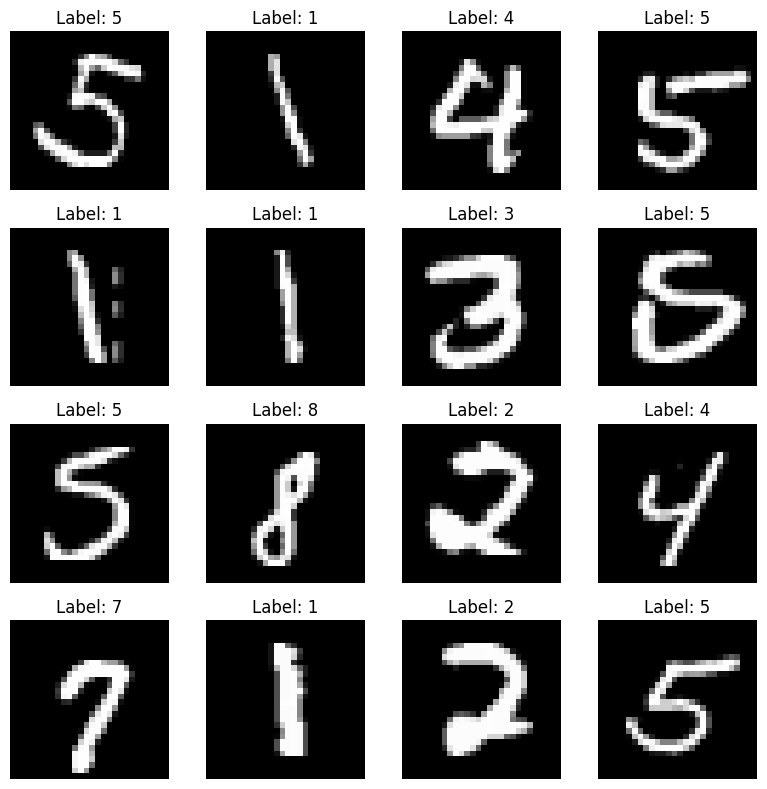

In [4]:
# 可视化样本
def show_samples(loader, num_samples=16):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            # 反归一化
            img = images[i].squeeze() * MNIST_STD + MNIST_MEAN
            ax.imshow(img, cmap='gray')
            ax.set_title(f'Label: {labels[i].item()}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_loader)

## 4. 模型定义

In [5]:
class SequenceTransformerClassifier(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=4, dim_feedforward=128, dropout=0.1, num_classes=10):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Linear(28, d_model)
        self.pos_encoding = nn.Parameter(torch.zeros(1, 28, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (batch, 1, 28, 28) -> (batch, 28, 28)
        x = x.squeeze(1)
        x = self.embedding(x) + self.pos_encoding
        x = self.transformer(x)
        # Use mean pooling of sequence
        x = x.mean(dim=1)
        return self.classifier(x)

model = SequenceTransformerClassifier(
    d_model=config['d_model'],
    nhead=config['nhead'],
    num_layers=config['num_layers'],
    dim_feedforward=config['dim_feedforward'],
    dropout=config['dropout'],
    num_classes=config['num_classes']
).to(device)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Model parameters: 138,186


## 5. 训练

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    """训练一个 epoch"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip_norm'])

        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """评估模型"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), correct / total

In [7]:
# 训练设置
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'])

# 记录训练历史
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Early stopping
best_val_acc = 0.0
patience_counter = 0
best_model_state = None

In [ ]:
# 训练循环
print('开始训练...')
for epoch in range(config['epochs']):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{config["epochs"]}: '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= config['early_stopping_patience']:
            print(f'Early stopping at epoch {epoch+1}')
            break

# 加载最佳模型
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f'\n加载最佳模型 (Val Acc: {best_val_acc:.4f})')

开始训练...
Epoch 1/10: Train Loss: 0.4843, Train Acc: 0.8433 | Val Loss: 0.1721, Val Acc: 0.9480
Epoch 2/10: Train Loss: 0.1379, Train Acc: 0.9591 | Val Loss: 0.1264, Val Acc: 0.9617
Epoch 3/10: Train Loss: 0.0979, Train Acc: 0.9701 | Val Loss: 0.1202, Val Acc: 0.9662
Epoch 4/10: Train Loss: 0.0743, Train Acc: 0.9781 | Val Loss: 0.0826, Val Acc: 0.9765


## 6. 训练曲线可视化

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss 曲线
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy 曲线
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 测试集评估
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'测试集 Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}')

## 7. 交互式演示 - 手写数字识别

在下方画布上绘制数字 (0-9)，然后点击预测按钮查看结果。

In [ ]:
from PIL import Image
import io

# 创建画布
canvas_width = 280
canvas_height = 280

canvas = widgets.Canvas(width=canvas_width, height=canvas_height, background_color='black')
clear_btn = widgets.Button(description='清除画布')
predict_btn = widgets.Button(description='预测', button_style='success')
output = widgets.Output()

# 绘图状态
drawing = [False]
last_x = [0]
last_y = [0]

def on_mouse_down(x, y):
    drawing[0] = True
    last_x[0] = x
    last_y[0] = y

def on_mouse_move(x, y):
    if drawing[0]:
        with hold_canvas(canvas):
            canvas.stroke_style = 'white'
            canvas.line_width = 20
            canvas.move_to(last_x[0], last_y[0])
            canvas.line_to(x, y)
            canvas.stroke()
        last_x[0] = x
        last_y[0] = y

def on_mouse_up(x, y):
    drawing[0] = False

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

def clear_canvas(b):
    canvas.clear()
    with output:
        clear_output()

def predict(b):
    # 获取画布图像
    canvas_data = canvas.to_image()

    # 转换为 PIL Image
    img = Image.open(io.BytesIO(canvas_data))

    # 转换为灰度并调整大小
    img = img.convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)

    # 转换为 tensor
    img_array = np.array(img) / 255.0
    # MNIST 是白字黑底，我们的画布也是黑底白字，但需要反转以匹配 MNIST 格式
    # MNIST 原始格式是白底黑字
    img_array = 1.0 - img_array  # 反转颜色

    # 归一化
    img_array = (img_array - MNIST_MEAN) / MNIST_STD

    # 转换为 tensor
    img_tensor = torch.tensor(img_array, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    img_tensor = img_tensor.to(device)

    # 预测
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = output.argmax(dim=1).item()

    # 显示结果
    with output:
        clear_output()
        print(f'预测结果: {pred}')

        # 绘制概率分布
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))

        # 输入图像
        axes[0].imshow(img_array, cmap='gray')
        axes[0].set_title('Input (28x28)')
        axes[0].axis('off')

        # 概率分布
        probs_np = probs[0].cpu().numpy()
        bars = axes[1].bar(range(10), probs_np, color='steelblue')
        bars[pred].set_color('red')
        axes[1].set_xlabel('Digit')
        axes[1].set_ylabel('Probability')
        axes[1].set_title('Prediction Probability')
        axes[1].set_xticks(range(10))
        axes[1].set_ylim([0, 1])

        plt.tight_layout()
        plt.show()

clear_btn.on_click(clear_canvas)
predict_btn.on_click(predict)

# 尝试导入 hold_canvas
try:
    from ipycanvas import hold_canvas
except ImportError:
    # 如果没有 ipycanvas，使用简化版本
    print('提示: 安装 ipycanvas 以获得更好的绘图体验: pip install ipycanvas')

    # 简化版本使用普通的绘图
    def on_mouse_move(x, y):
        if drawing[0]:
            canvas.stroke_style = 'white'
            canvas.line_width = 20
            canvas.move_to(last_x[0], last_y[0])
            canvas.line_to(x, y)
            canvas.stroke()
            last_x[0] = x
            last_y[0] = y

display(widgets.VBox([
    widgets.HTML('<b>在下方画布上绘制数字 (0-9):</b>'),
    canvas,
    widgets.HBox([clear_btn, predict_btn]),
    output
]))

## 说明

1. **模型架构**: 使用 Transformer 编码器将 MNIST 图像视为 784 个 token 的序列
2. **训练**: 使用 AdamW 优化器 + Cosine Annealing 学习率调度
3. **演示**: 在画布上绘制数字，模型会实时预测并显示概率分布